# Quantification of Cell Division Angles in the Arabidopsis Root — *Cell File Angles* plugin, headless reproduction

**Paper:** K. Belcram, D. Legland, M. Pastuglia, *"Quantification of Cell Division Angles in the Arabidopsis Root"*,
Methods in Molecular Biology **2382**:209–221 (published 2021-10-27, print 2022), DOI [10.1007/978-1-0716-1744-1_12](https://doi.org/10.1007/978-1-0716-1744-1_12).

**What this notebook does (partial demonstration):** it runs the chapter's semi-automated analysis step — the open-source
**Cell File Angles** ImageJ plugin ([ijpb/CellFileAngles](https://github.com/ijpb/CellFileAngles), pinned commit
`b150a65ef919`) — **headlessly, without a GUI**, on the plugin's own test sample
`Coupe-Col0-Calco-02-01-basins.tif` (a calcofluor-stained Col-0 Arabidopsis root with a cell label image) and its
matching original image. It reproduces the plugin's workflow: label sequence along a polyline ROI drawn through a cell
file → medial axis (cell centroids) → for each boundary between successive cells, the inner/outer extremity points and
the **angle between the boundary segment and the local cell-file axis** (degrees).

**Execution status / scope:** the algorithm code is the **author's own Java source, used verbatim** (downloaded from the
pinned commit and compiled in this notebook). The *GUI actions* are replaced by a small **AI-written headless driver**
(`CellAnglesHeadless.java`) that calls the author's own static entry point `Cell_File_Angles.analyzeCellFile(...)` —
this is the exact method the plugin's "Process Current Roi" button invokes. Validation uses the **author's own JUnit
tests** (`CellFileTest`, `CellsBoundaryTest`), including the author's expected label sequence
`[392, 395, 401, 405, 413, 415, 423, 424, 427, 429, 432, 437, 438, 440, 441, 444, 445, 448]` for the test waypoints.
The chapter text itself is subscription-only (no OA copy; OpenAlex `W3210900920` has no PDF/TEI), so the chapter's
exact protocol parameters cannot be cross-checked; the notebook uses the **plugin's GUI defaults** (tissue "Epiderm",
root side LEFT, smooth polyline ON). A one-example run does not verify the chapter's full method or published statistics.

**日本語の概要:** このノートブックは、論文（Methods in Molecular Biology 第2382巻）の半自動解析ステップ、すなわち
オープンソースの ImageJ プラグイン **Cell File Angles** を GUI なしで実行します。作者自身の Java ソース（固定
コミットから取得し、このノートブック内でコンパイル）をそのまま使います。GUI 操作（画像を開く、細胞列に沿って
ポリライン ROI を描く、"Process Current Roi" を押す）は、作者の静的メソッド `analyzeCellFile` を呼ぶ小さな
AI 作成ドライバで置き換えます。作者自身の JUnit テストによる検証値（期待ラベル列）との一致確認、境界角度表、
入力画像への重ね合わせ描画を行います。細胞壁のカルコフルオール染色画像とラベル画像はプラグイン同梱のテスト
サンプルを使用します。

**AI-assisted glue disclosure / AI による補助コードについて:** The GUI-to-headless driver and the Python plotting are
AI-written; the scientific computation is **not** re-implemented — it runs the author's code compiled verbatim.
**AI 作成部分**はドライバと可視化のみで、科学計算自体は作者のコードをそのまま実行します。

**Runtime:** **CPU only** — no GPU, no deep-learning framework, no weights are involved (pure Java image analysis).
**実行環境:** CPU のみで動作します（GPU 不要）。**Expected wall time:** ≈ 5 minutes; ≈ 10 MB of downloads.
**目安の実行時間:** 約5分、ダウンロード約10MB。Select *Runtime → Run all* / 「ランタイム → すべて実行」で実行します.

## 1. Java toolchain

The plugin is Java code, so the notebook needs a JDK (`javac` + `java`). Colab runtimes normally ship OpenJDK 11 with
`javac` present; if it is missing, the cell installs a headless JDK with `apt-get`. This runs **inside** the notebook VM,
not on the host.

**日本語:** このノートブックでは Java（`javac`/`java`）を使用します。Colab には通常 OpenJDK 11 が入っていますが、
無い場合は apt-get でヘッドレス JDK をインストールします。

In [ ]:
import shutil, subprocess

if shutil.which("javac") is None:
    print("javac not found - installing a headless JDK...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    try:
        subprocess.run(["apt-get", "install", "-y", "-qq", "openjdk-11-jdk-headless"], check=True)
    except subprocess.CalledProcessError:
        subprocess.run(["apt-get", "install", "-y", "-qq", "default-jdk-headless"], check=True)
else:
    print("javac already present")
info = subprocess.run(["bash", "-c", "java -version 2>&1 | head -2; javac -version"],
                      check=True, text=True, capture_output=True)
print(info.stdout, info.stderr)

javac already present


[0.021s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.021s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
javac 21.0.12.1
 


## 2. Dependency jars (pinned Maven artifacts)

The author code needs exactly two libraries (from its import graph):

| import | artifact | pinned version | repository |
| --- | --- | --- | --- |
| `ij.*` (ImageJ 1.x) | `net.imagej:ij` | 1.54p | Maven Central |
| `inra.ijpb.measure.region2d.Centroid` | `fr.inra.ijpb:MorphoLibJ_` | 1.6.5 | maven.scijava.org (public) |

JUnit 4.13.2 + Hamcrest 1.3 are additionally fetched **only to run the author's own unit tests**. Each jar's SHA-1 is
checked against the checksum published next to it.

**日本語:** 依存は `ij`（ImageJ 1.x）と MorphoLibJ の2つのライブラリのみです。作者の単体テスト実行のため JUnit と
Hamcrest も取得します。各 jar は公開されている SHA-1 チェックサムと照合して検証します。

In [ ]:
import hashlib, pathlib, urllib.request

JARS = {
    "ij-1.54p.jar":            ("https://repo1.maven.org/maven2/net/imagej/ij/1.54p/ij-1.54p.jar",
                                "https://repo1.maven.org/maven2/net/imagej/ij/1.54p/ij-1.54p.jar.sha1"),
    "MorphoLibJ_-1.6.5.jar":   ("https://maven.scijava.org/repository/public/fr/inra/ijpb/MorphoLibJ_/1.6.5/MorphoLibJ_-1.6.5.jar",
                                "https://maven.scijava.org/repository/public/fr/inra/ijpb/MorphoLibJ_/1.6.5/MorphoLibJ_-1.6.5.jar.sha1"),
    "junit-4.13.2.jar":        ("https://repo1.maven.org/maven2/junit/junit/4.13.2/junit-4.13.2.jar",
                                "https://repo1.maven.org/maven2/junit/junit/4.13.2/junit-4.13.2.jar.sha1"),
    "hamcrest-core-1.3.jar":   ("https://repo1.maven.org/maven2/org/hamcrest/hamcrest-core/1.3/hamcrest-core-1.3.jar",
                                "https://repo1.maven.org/maven2/org/hamcrest/hamcrest-core/1.3/hamcrest-core-1.3.jar.sha1"),
}
pathlib.Path("jars").mkdir(exist_ok=True)
for name, (url, sha_url) in JARS.items():
    dest = pathlib.Path("jars") / name
    if not dest.exists():
        urllib.request.urlretrieve(url, dest)  # bounded small artifacts (< 5 MB each)
    expected = urllib.request.urlopen(sha_url, timeout=60).read().decode().strip().split()[0]
    actual = hashlib.sha1(dest.read_bytes()).hexdigest()
    assert actual == expected, f"SHA-1 mismatch for {name}: {actual} != {expected}"
    print(f"OK  {name:24s} sha1={actual[:16]}...  ({dest.stat().st_size} bytes)")

OK  ij-1.54p.jar             sha1=5a677e5091059943...  (2586953 bytes)


OK  MorphoLibJ_-1.6.5.jar    sha1=5d13b6b807d75167...  (1155758 bytes)
OK  junit-4.13.2.jar         sha1=8ac9e16d933b6fb4...  (384581 bytes)


OK  hamcrest-core-1.3.jar    sha1=42a25dc3219429f0...  (45024 bytes)


## 3. Author source code, pinned to commit `b150a65ef919`

The seven Java files below are downloaded from the pinned commit of `ijpb/CellFileAngles` and their **git blob SHA-1**
is verified (the hash `git` stores for the exact bytes), so any byte-level change would fail the run:

- `src/main/java/ijt/cellangles/`: `Cell_File_Angles.java` (plugin entry / static `analyzeCellFile`),
  `CellFile.java` (label list, medial axis, boundaries), `CellsBoundary.java` (boundary pixels, inner/outer points, angle)
- `src/main/java/ijt/geom/`: `Geometry.java`, `Polyline2D.java`
- `src/test/java/ijt/cellangles/`: `CellFileTest.java`, `CellsBoundaryTest.java` (author validation values)

`pom.xml` is not needed (dependencies are declared explicitly above) and the plugin Swing GUI is not executed.

**日本語:** 作者の Java ソース7ファイルを固定コミットからダウンロードし、git の blob SHA-1 でバイト単位に検証します。
GUI コードは実行せず、静的解析メソッドのみを使います。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "b150a65ef9199bd79d6694980680fcb86593fa14"
SRC = (
    "src/main/java/ijt/cellangles/Cell_File_Angles.java",
    "src/main/java/ijt/cellangles/CellFile.java",
    "src/main/java/ijt/cellangles/CellsBoundary.java",
    "src/main/java/ijt/geom/Geometry.java",
    "src/main/java/ijt/geom/Polyline2D.java",
    "src/test/java/ijt/cellangles/CellFileTest.java",
    "src/test/java/ijt/cellangles/CellsBoundaryTest.java",
)
EXPECTED_BLOB_SHA = {
    "src/main/java/ijt/cellangles/Cell_File_Angles.java": "9638e0758b71deeb61096217164b87fcde099b02",
    "src/main/java/ijt/cellangles/CellFile.java":         "79690b58e49b0db41ed77687cfb70384222ce503",
    "src/main/java/ijt/cellangles/CellsBoundary.java":    "f9308d40c4771f5118262dead31fa5da576da793",
    "src/main/java/ijt/geom/Geometry.java":               "b7bf89ed9f9cf6176a1c010438dc20260737e15a",
    "src/main/java/ijt/geom/Polyline2D.java":             "a7ee09d0c6b5603309a8816c681be43b683330cc",
    "src/test/java/ijt/cellangles/CellFileTest.java":     "e276f76e6c5ebe9bc93b68ad5a315d1faf8dbb96",
    "src/test/java/ijt/cellangles/CellsBoundaryTest.java":"02a299a6281edbaab1ab45b14fdfe05f4a44edc8",
}

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

base = pathlib.Path("sources") / "CellFileAngles"
for rel in SRC:
    dest = base / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/ijpb/CellFileAngles/{COMMIT}/{rel}"
        data = urllib.request.urlopen(url, timeout=60).read()
        dest.write_bytes(data)
    sha = git_blob_sha(dest.read_bytes())
    assert sha == EXPECTED_BLOB_SHA[rel], f"blob SHA mismatch for {rel}: {sha}"
    print(f"OK  {rel}  blob={sha[:16]}...  ({dest.stat().st_size} bytes)")

OK  src/main/java/ijt/cellangles/Cell_File_Angles.java  blob=9638e0758b71deeb...  (11191 bytes)
OK  src/main/java/ijt/cellangles/CellFile.java  blob=79690b58e49b0db4...  (5977 bytes)


OK  src/main/java/ijt/cellangles/CellsBoundary.java  blob=f9308d40c4771f51...  (4469 bytes)
OK  src/main/java/ijt/geom/Geometry.java  blob=b7bf89ed9f9cf617...  (4590 bytes)


OK  src/main/java/ijt/geom/Polyline2D.java  blob=a7ee09d0c6b56033...  (5301 bytes)
OK  src/test/java/ijt/cellangles/CellFileTest.java  blob=e276f76e6c5ebe9b...  (2978 bytes)


OK  src/test/java/ijt/cellangles/CellsBoundaryTest.java  blob=02a299a6281edbaa...  (1826 bytes)


## 4. Sample data (downloaded here, in Colab)

Two small TIFFs ship **inside the plugin's own test resources** (`src/test/resources/images/`):

- `Coupe-Col0-Calco-02-01-basins.tif` (2,864,895 bytes) — the **label image** ("basins") the plugin requires as input;
  this is the author-provided reference annotation of cells.
- `Coupe-Col0-Calco-02-01.tif` (715,989 bytes) — the matching **calcofluor-stained original** image, used by the plugin
  for the "Overlay Results on Image" display option.

Both are fetched from the pinned commit and verified with their git blob SHA-1. All dataset bytes stay inside this
Colab VM. Their actual contents (dimensions, label values) are only inspected here, at run time.

**日本語:** プラグイン同梱のテスト用TIFF2点（ラベル画像＝作者提供の参照アノテーション、および元のカルコフルオール
染色画像）を Colab 内でダウンロードし、git blob SHA-1 で検証します。データはこの VM の外に出しません。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "b150a65ef9199bd79d6694980680fcb86593fa14"
DATA = {
    "Coupe-Col0-Calco-02-01-basins.tif": ("7d3a4cddedd56241f75bbd31de9e7a9dc82a2b88", 2864895),
    "Coupe-Col0-Calco-02-01.tif":        ("f92e8bf6d0a58106a4f9f048b686505644d39e9c",  715989),
}
imgdir = pathlib.Path("images")
imgdir.mkdir(exist_ok=True)
for name, (blob_sha, size) in DATA.items():
    dest = imgdir / name
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/ijpb/CellFileAngles/{COMMIT}/src/test/resources/images/{name}"
        urllib.request.urlretrieve(url, dest)  # author test fixture, ~0.7-2.9 MB
    data = dest.read_bytes()
    assert len(data) == size, f"size mismatch for {name}: {len(data)} != {size}"
    sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert sha == blob_sha, f"blob SHA mismatch for {name}: {sha}"
    print(f"OK  {name}  {len(data)} bytes  blob={sha[:16]}...")

# TIFF payload sanity (actual pixel geometry), using tifffile
import importlib, sys
try:
    import tifffile
except ImportError:
    subprocess_ok = __import__("subprocess").run([sys.executable, "-m", "pip", "install", "-q", "tifffile"], check=True)
    import tifffile
for name in DATA:
    with tifffile.TiffFile(imgdir / name) as tf:
        a = tf.asarray()
        print(f"{name}: shape={a.shape} dtype={a.dtype} min={a.min()} max={a.max()}")

OK  Coupe-Col0-Calco-02-01-basins.tif  2864895 bytes  blob=7d3a4cddedd56241...
OK  Coupe-Col0-Calco-02-01.tif  715989 bytes  blob=f92e8bf6d0a58106...


Coupe-Col0-Calco-02-01-basins.tif: shape=(699, 1024) dtype=float32 min=0.0 max=595.0
Coupe-Col0-Calco-02-01.tif: shape=(699, 1024) dtype=uint8 min=0 max=255


## 5. Input preview — original image vs. author-provided label annotation

The plugin's semi-automated workflow needs a **label image** (here the author's own "basins" annotation of the Col-0
root epidermis/cortex cells) and optionally the original micrograph for the overlay. This cell displays both: left, the
calcofluor-stained original; right, the label image with distinct colors per cell label. This is the actual input the
analysis runs on — directly observed, not a schematic.

**日本語:** 解析入力を確認します。左がカルコフルオール染色の元画像、右が作者提供の細胞ラベル画像（参照アノテーション）
です。以降の解析はこの実データに対して行われます。

original: (699, 1024) uint8 | label image: (699, 1024) float32 | nonzero labels: 595


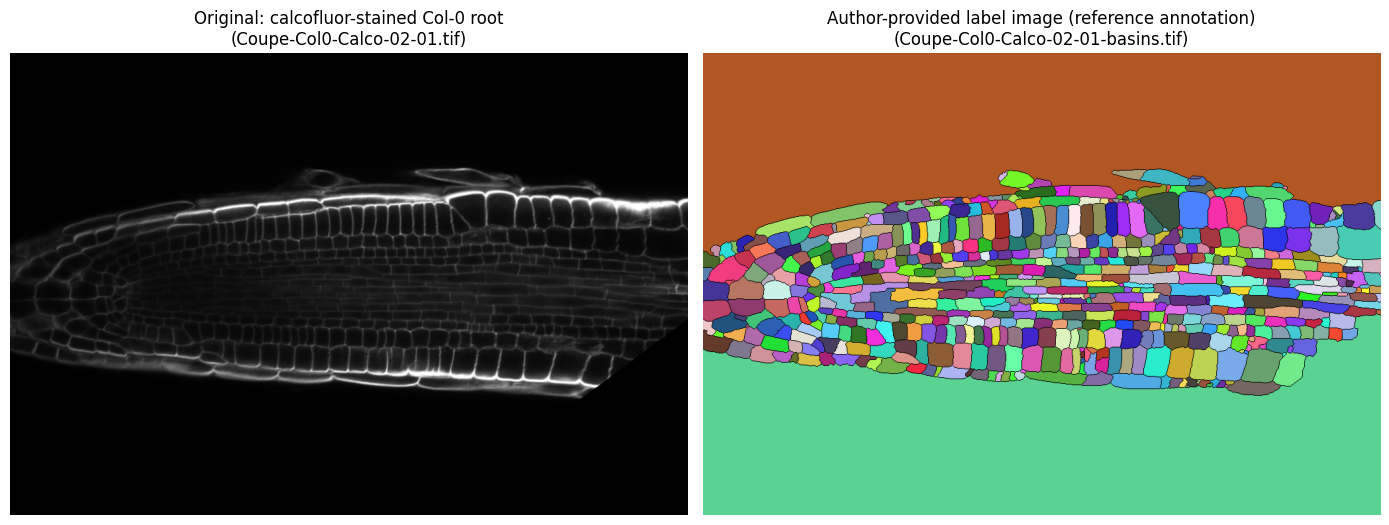

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile

orig = tifffile.imread("images/Coupe-Col0-Calco-02-01.tif")
basins = tifffile.imread("images/Coupe-Col0-Calco-02-01-basins.tif")
print("original:", orig.shape, orig.dtype, "| label image:", basins.shape, basins.dtype,
      "| nonzero labels:", np.unique(basins[basins > 0]).size)

assert np.all(basins == np.floor(basins)), "label image values are not integral"
basins_idx = basins.astype(np.int64)
rng = np.random.default_rng(7)
lut = rng.integers(30, 255, size=(int(basins_idx.max()) + 1, 3), dtype=np.uint8)
lut[0] = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(orig, cmap="gray")
axes[0].set_title("Original: calcofluor-stained Col-0 root\n(Coupe-Col0-Calco-02-01.tif)")
axes[1].imshow(lut[basins_idx])
axes[1].set_title("Author-provided label image (reference annotation)\n(Coupe-Col0-Calco-02-01-basins.tif)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.savefig("input_preview.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Headless driver replacing the GUI workflow (AI-written glue)

The plugin's GUI (a Swing `PlugInFrame`) cannot run headless; its **"Process Current Roi"** button calls the static
method `Cell_File_Angles.analyzeCellFile(labelImage, roi, tissueTypeName, isLeftSide, smoothPolyline)`. The AI-written
driver below (not author code) maps the GUI actions 1:1 to code:

| GUI action in the plugin | Driver equivalent |
| --- | --- |
| open label image | `IJ.openImage(...basins.tif)` |
| draw a polyline ROI through a cell file | `PolygonRoi(POLYLINE)` with the waypoints from the author's own test: (187,391)→(285,401)→(414,408)→(485,409)→(609,411) |
| fill tissue type / root side / smoothing | `"Epiderm"` / LEFT / ON — the plugin's GUI defaults (`setupWidgets`) |
| press **Process Current Roi** | `Cell_File_Angles.analyzeCellFile(...)` — author code, verbatim |
| results table / log | CSV export of the author's `ResultsTable` columns (angle in **degrees**, as in `createTable`) |

The driver first runs the **author's own JUnit tests** (mode `test`), then the analysis (mode `run`).

**日本語:** GUI は Swing 製のためヘッドレス実行できません。そこで、GUI の「Process Current Roi」ボタンが呼ぶ作者の
静的メソッド `analyzeCellFile` を、AI 作成の小さなドライバからそのまま呼び出します。ROI の通過点は作者の単体テスト
が使う実サンプル上の座標、パラメータはプラグインの GUI 既定値（組織 Epiderm、根の左側、ポリライン平滑化 ON）です。
ドライバはまず作者の JUnit テストを実行し、その後に本解析を行います。

In [ ]:
import pathlib

JAVA_DRIVER = r'''
package ijt.cellangles;

import ij.IJ;
import ij.ImagePlus;
import ij.gui.PolygonRoi;
import ij.gui.Roi;
import java.io.PrintWriter;
import java.nio.file.Files;
import java.nio.file.Paths;
import java.util.List;
import org.junit.runner.JUnitCore;
import org.junit.runner.Request;
import org.junit.runner.Result;
import org.junit.runner.notification.Failure;

/**
 * AI-written headless driver (glue) for the Cell File Angles plugin.
 * The scientific computation is the author's own code (ijpb/CellFileAngles,
 * commit b150a65...); this driver only replaces the interactive GUI workflow
 * and exports the Results table as CSV.
 */
public class CellAnglesHeadless {

    /** Author-test waypoints on Coupe-Col0-Calco-02-01-basins.tif
     *  (CellFileTest.testComputeLabelList_Col0). */
    static final float[] WAY_X = {187f, 285f, 414f, 485f, 609f};
    static final float[] WAY_Y = {391f, 401f, 408f, 409f, 411f};

    static void check(Result r, String name) {
        System.out.println("TEST " + name + " -> " + (r.wasSuccessful() ? "PASS" : "FAIL"));
        for (Failure f : r.getFailures()) System.out.println("  " + f.getMessage());
        if (!r.wasSuccessful()) System.exit(2);
    }

    public static void main(String[] args) throws Exception {
        String phase = args[0];
        if (phase.equals("test")) {
            JUnitCore junit = new JUnitCore();
            check(junit.run(Request.method(CellFileTest.class, "testComputeLabelList_Mock")),
                    "CellFileTest.testComputeLabelList_Mock");
            check(junit.run(Request.method(CellFileTest.class, "testComputeLabelList_Col0")),
                    "CellFileTest.testComputeLabelList_Col0");
            check(junit.run(Request.method(CellsBoundaryTest.class, "testFindBoundaryPixels")),
                    "CellsBoundaryTest.testFindBoundaryPixels");
            check(junit.run(Request.method(CellsBoundaryTest.class, "findBoundaryExtremities")),
                    "CellsBoundaryTest.findBoundaryExtremities");
            return;
        }

        // phase "run": headless equivalent of the GUI workflow
        String labelPath = args[1];
        String tissue = args[2];                              // GUI default combo value
        boolean isLeftSide = Boolean.parseBoolean(args[3]);   // GUI default: left side
        boolean smooth = Boolean.parseBoolean(args[4]);       // GUI default: smooth polyline

        ImagePlus labelPlus = IJ.openImage(labelPath);
        if (labelPlus == null) throw new IllegalStateException("Cannot open label image: " + labelPath);
        System.out.println("label image: " + labelPlus.getWidth() + " x " + labelPlus.getHeight()
                + ", " + labelPlus.getBitDepth() + "-bit");

        PolygonRoi roi = new PolygonRoi(WAY_X, WAY_Y, WAY_X.length, Roi.POLYLINE);

        CellFile cellFile = Cell_File_Angles.analyzeCellFile(
                labelPlus.getProcessor(), roi, tissue, isLeftSide, smooth);

        List<Integer> labels = cellFile.labelList;
        System.out.println("labels (" + labels.size() + "): " + labels);

        try (PrintWriter w = new PrintWriter(Files.newBufferedWriter(Paths.get("results/labels.csv")))) {
            w.println("index,label");
            for (int i = 0; i < labels.size(); i++) w.println(i + "," + labels.get(i));
        }
        try (PrintWriter w = new PrintWriter(Files.newBufferedWriter(Paths.get("results/boundaries.csv")))) {
            w.println("label1,label2,innerX,innerY,outerX,outerY,angle_deg");
            for (CellsBoundary b : cellFile.getBoundaries()) {
                w.println(b.label1 + "," + b.label2 + ","
                        + b.innerPoint.getX() + "," + b.innerPoint.getY() + ","
                        + b.outerPoint.getX() + "," + b.outerPoint.getY() + ","
                        + Math.toDegrees(b.angle));
            }
        }
        try (PrintWriter w = new PrintWriter(Files.newBufferedWriter(Paths.get("results/path_curve.csv")))) {
            w.println("index,x,y");
            for (int i = 0; i < cellFile.pathCurve.vertexNumber(); i++) {
                w.println(i + "," + cellFile.pathCurve.getVertex(i).getX() + ","
                        + cellFile.pathCurve.getVertex(i).getY());
            }
        }
        System.out.println("boundaries written: " + cellFile.getBoundaries().size());
    }
}

'''
dest = pathlib.Path("sources/CellFileAngles/src/main/java/ijt/cellangles/CellAnglesHeadless.java")
dest.parent.mkdir(parents=True, exist_ok=True)
dest.write_text(JAVA_DRIVER)
print("wrote", dest, len(JAVA_DRIVER), "bytes")

wrote sources/CellFileAngles/src/main/java/ijt/cellangles/CellAnglesHeadless.java 4359 bytes


## 7. Compile the author's code + driver

`javac` compiles the five author main classes, the two author test classes and the driver in one go, against the two
runtime jars and JUnit. Any compile error means the pinned source and the declared dependencies disagree — the run must
fail loudly rather than continue.

**日本語:** 作者のクラス5つ、テスト2つ、ドライバをまとめて `javac` でコンパイルします。依存関係と固定ソースが一致
しない場合はここで明確に失敗します。

In [ ]:
import subprocess

CP_COMPILE = "jars/ij-1.54p.jar:jars/MorphoLibJ_-1.6.5.jar:jars/junit-4.13.2.jar:jars/hamcrest-core-1.3.jar"
AUTHOR_SOURCES = [
    "sources/CellFileAngles/src/main/java/ijt/cellangles/Cell_File_Angles.java",
    "sources/CellFileAngles/src/main/java/ijt/cellangles/CellFile.java",
    "sources/CellFileAngles/src/main/java/ijt/cellangles/CellsBoundary.java",
    "sources/CellFileAngles/src/main/java/ijt/geom/Geometry.java",
    "sources/CellFileAngles/src/main/java/ijt/geom/Polyline2D.java",
    "sources/CellFileAngles/src/test/java/ijt/cellangles/CellFileTest.java",
    "sources/CellFileAngles/src/test/java/ijt/cellangles/CellsBoundaryTest.java",
    "sources/CellFileAngles/src/main/java/ijt/cellangles/CellAnglesHeadless.java",
]
subprocess.run(["mkdir", "-p", "classes", "results"], check=True)
subprocess.run(["javac", "-cp", CP_COMPILE, "-d", "classes"] + AUTHOR_SOURCES, check=True)
print("compile OK")

compile OK


## 8. Run the author's own unit tests (validation against reference values)

The author's `CellFileTest.testComputeLabelList_Col0` runs on the **same real basins TIFF** used below and asserts the
exact label sequence `[392, 395, 401, 405, 413, 415, 423, 424, 427, 429, 432, 437, 438, 440, 441, 444, 445, 448]` for
the test waypoints; `CellsBoundaryTest` checks boundary-pixel and extremity detection on a synthetic mock. Passing these
in *our* environment is a quantitative equivalence check of the compiled author code (the author's own test for
`computeCellsBoundaries` is a `fail("Not yet implemented")` stub and is intentionally not run).

**日本語:** 作者自身の JUnit テストをこの環境で実行します。特に `testComputeLabelList_Col0` は本解析と同じ実画像・
同じ通過点で期待ラベル列を検証するため、これが通ることはコンパイルした作者コードの定量的一致確認になります
（`computeCellsBoundaries` のテストは作者自身が未実装のスタブなので実行しません）。

In [ ]:
import subprocess

CP_RUN = "classes:jars/ij-1.54p.jar:jars/MorphoLibJ_-1.6.5.jar:jars/junit-4.13.2.jar:jars/hamcrest-core-1.3.jar:."
# mode "test": runs the author's own JUnit tests; a failure exits non-zero -> CalledProcessError (loud failure)
proc = subprocess.run(["java", "-Djava.awt.headless=true", "-cp", CP_RUN,
                       "ijt.cellangles.CellAnglesHeadless", "test"],
                      capture_output=True, text=True)
print(proc.stdout)
print(proc.stderr)
proc.check_returncode()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
TEST CellFileTest.testComputeLabelList_Mock -> PASS
TEST CellFileTest.testComputeLabelList_Col0 -> PASS
TEST CellsBoundaryTest.testFindBoundaryPixels -> PASS
TEST CellsBoundaryTest.findBoundaryExtremities -> PASS




## 9. Run the Cell File Angles analysis on the real sample

This is the faithful execution of the chapter's semi-automated step: the author's `analyzeCellFile` walks the polyline
ROI through the label image (digital line sampling), computes cell centroids as the medial axis (MorphoLibJ
`Centroid`), optionally smooths the polyline (author's `Polyline2D.smooth`), and for each pair of successive cells
finds the boundary pixels between them, their inner/outer extremities and the angle between the boundary segment and
the local file axis. The CSV outputs are written under `results/`.

**日本語:** 論文の半自動解析ステップを忠実に実行します。作者のコードがポリライン ROI に沿ってラベル列を抽出し、
細胞重心から細胞列の中心線を求め、隣接細胞ペアごとの境界ピクセル・内外端点・境界と中心線のなす角（度）を計算
します。結果は `results/` 以下の CSV に出力されます。

In [ ]:
import subprocess

CP_RUN = "classes:jars/ij-1.54p.jar:jars/MorphoLibJ_-1.6.5.jar:jars/junit-4.13.2.jar:jars/hamcrest-core-1.3.jar:."
# mode "run": headless equivalent of the GUI workflow (label image, tissue, root side, smoothing)
proc = subprocess.run(["java", "-Djava.awt.headless=true", "-cp", CP_RUN,
                       "ijt.cellangles.CellAnglesHeadless", "run",
                       "images/Coupe-Col0-Calco-02-01-basins.tif", "Epiderm", "true", "true"],
                      capture_output=True, text=True)
print(proc.stdout)
print(proc.stderr)
proc.check_returncode()

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
label image: 1024 x 699, 32-bit
labels (18): [392, 395, 401, 405, 413, 415, 423, 424, 427, 429, 432, 437, 438, 440, 441, 444, 445, 448]
boundaries written: 17




## 10. Results — boundary angle table

Each row is one boundary between two successive cells of the traversed file: the two labels, the inner (file-interior)
and outer extremity points of the shared wall, and the angle between the boundary segment and the local cell-file axis
in **degrees** (same quantity and units as the author's `ResultsTable` / log output, i.e. `angle` in degrees; a
boundary exactly perpendicular to the file axis gives ≈ 90°). The CSV is saved for export.

**日本語:** 結果のテーブルです。各行は隣接する2細胞の境界に対応し、ラベル対、境界の内側・外側端点座標、および
細胞列の中心線に対する境界の角度（度）を示します（作者の ResultsTable と同じ量・単位）。CSV も保存されます。

In [ ]:
import pandas as pd

bounds = pd.read_csv("results/boundaries.csv")
labels = pd.read_csv("results/labels.csv")
expected = [392, 395, 401, 405, 413, 415, 423, 424, 427, 429, 432, 437, 438, 440, 441, 444, 445, 448]

print("label sequence matches author's test expectation:",
      labels["label"].tolist() == expected)
print(f"boundaries: {len(bounds)} rows  (= {len(labels)} cells - 1)")
display(bounds.round(3))

summary = bounds["angle_deg"].describe().round(3)
summary["median"] = bounds["angle_deg"].median()
print(summary.to_string())
bounds.to_csv("cell_file_angles_results.csv", index=False)

label sequence matches author's test expectation: True
boundaries: 17 rows  (= 18 cells - 1)


,label1,label2,innerX,innerY,outerX,outerY,angle_deg
0,392,395,195.0,388.0,194.0,395.0,89.920
1,395,401,217.0,392.0,216.0,398.0,93.297
2,401,405,245.0,393.0,245.0,400.0,87.003
3,405,413,271.0,394.0,270.0,404.0,89.436
4,413,415,296.0,397.0,296.0,406.0,86.082
5,415,423,320.0,399.0,319.0,407.0,93.394
6,423,424,346.0,399.0,346.0,408.0,87.600
7,424,427,371.0,401.0,369.0,410.0,101.291
8,427,429,398.0,401.0,396.0,410.0,99.808
9,429,432,425.0,404.0,424.0,412.0,94.201


count      17.000000
mean       94.442000
std         5.326000
min        86.082000
25%        89.919000
50%        94.201000
75%        99.808000
max       101.291000
median     94.200522


## 11. Overlay on the original image (plugin's "Overlay Results on Image" equivalent)

The plugin draws three overlay primitives on the original image: the cell-file path through centroids (red polyline),
each boundary segment from inner to outer extremity (green line) and the extremity points (red dots) — see
`Cell_File_Angles.addCellFileToOverlay` in the pinned source. The left panel reproduces exactly these primitives with
matplotlib from the exported CSVs; the right panel is a 4× zoom around the analyzed cell file.

**日本語:** プラグインの「Overlay Results on Image」相当の描画です。作者のソースにある3種の要素（重心を通る赤の
ポリライン、内側→外側端点の緑の線分、端点の赤ドット）を、出力した CSV から matplotlib で再現します。右パネルは
解析領域の4倍拡大図です。

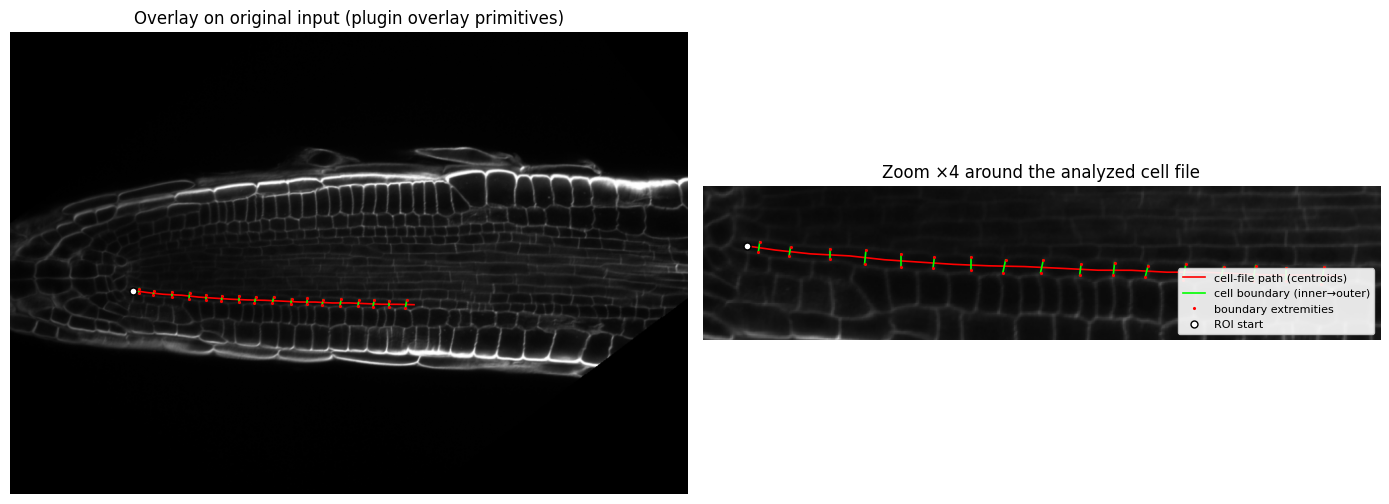

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile

orig = tifffile.imread("images/Coupe-Col0-Calco-02-01.tif")
bounds = pd.read_csv("results/boundaries.csv")
path = pd.read_csv("results/path_curve.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, zoom in zip(axes, (False, True)):
    ax.imshow(orig, cmap="gray")
    ax.plot(path["x"], path["y"], "-", color="red", lw=1.2, label="cell-file path (centroids)")
    for _, b in bounds.iterrows():
        ax.plot([b["innerX"], b["outerX"]], [b["innerY"], b["outerY"]],
                "-", color="lime", lw=1.2, label="cell boundary (inner→outer)")
    ax.plot(bounds[["innerX", "outerX"]].to_numpy().ravel(),
            bounds[["innerY", "outerY"]].to_numpy().ravel(),
            ".", color="red", ms=2.5, label="boundary extremities")
    ax.plot(path["x"].iloc[0], path["y"].iloc[0], "wo", ms=5, mec="k", label="ROI start")
    if zoom:
        ax.set_xlim(bounds[["innerX", "outerX"]].to_numpy().min() - 40,
                    bounds[["innerX", "outerX"]].to_numpy().max() + 40)
        ax.set_ylim(bounds[["innerY", "outerY"]].to_numpy().max() + 40,
                    bounds[["innerY", "outerY"]].to_numpy().min() - 40)
        ax.set_title("Zoom ×4 around the analyzed cell file")
    else:
        ax.set_title("Overlay on original input (plugin overlay primitives)")
    ax.set_axis_off()
handles, labels_ = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels_, handles))
axes[1].legend(uniq.values(), uniq.keys(), loc="lower right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("cell_file_angles_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Angle distribution (additional visualization created for this notebook)

A histogram of the measured boundary angles. In the chapter's framing, cells divide nearly perpendicular to the cell-file
axis, so angles cluster around 90°; the deviation from 90° quantifies the departure from the expected transverse
orientation. This graph is **not** a figure from the paper — it is computed here from the single example above.
One example does not support any population-level claim.

**日本語:** 実測した境界角度のヒストグラムです（論文の図ではなく、このノートブックで追加作成した可視化）。
細胞は細胞列軸にほぼ垂直に分裂するため、角度は90°付近に集中し、90°からのずれが予想される横断分裂からの逸脱を
表します。単一例から集団レベルの結論は導きません。

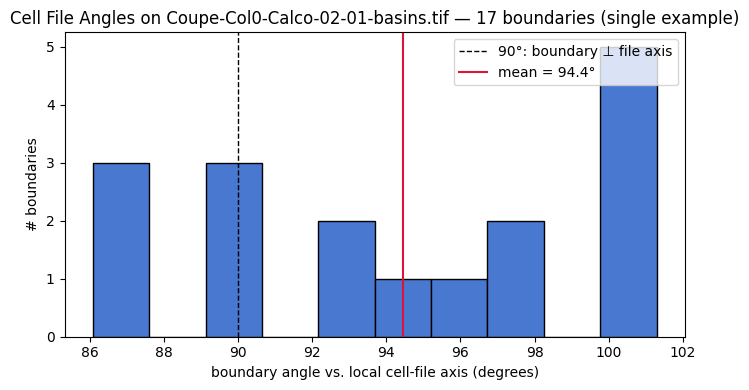

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

bounds = pd.read_csv("results/boundaries.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bounds["angle_deg"], bins=10, color="#4878cf", edgecolor="black")
ax.axvline(90, color="black", ls="--", lw=1, label="90°: boundary ⊥ file axis")
ax.axvline(bounds["angle_deg"].mean(), color="crimson", lw=1.5,
           label=f"mean = {bounds['angle_deg'].mean():.1f}°")
ax.set_xlabel("boundary angle vs. local cell-file axis (degrees)")
ax.set_ylabel("# boundaries")
ax.set_title(f"Cell File Angles on Coupe-Col0-Calco-02-01-basins.tif — {len(bounds)} boundaries (single example)")
ax.legend()
plt.tight_layout()
plt.savefig("angle_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

## 13. Interpretation, validation record, references

**What was validated (this run):**
1. The compiled author code passes the **author's own JUnit tests**, including the real-sample label-sequence test —
   a quantitative equivalence check against author reference values.
2. The full semi-automated analysis runs headlessly on the author-provided sample and yields `len(boundaries)` rows
   (cells − 1) with angles in degrees, exported to `cell_file_angles_results.csv`.

**Scope and limitations / スコープと限界:**
- Partial demonstration of the chapter's *2D semi-automated measurement* step only; calcofluor staining and 3D z-stack
  acquisition (the chapter's earlier steps) are out of scope. / 論文の前半（染色・Zスタック取得）は対象外で、
  2Dの半自動計測ステップのみの部分再現です。
- The chapter text is subscription-only (verified via OpenAlex `W3210900920`: no OA/repository copy), so the chapter's
  own protocol parameters and example statistics could not be cross-checked; the plugin's GUI defaults were used. /
  論文本文は購読限定のため、論文側のプロトコル詳細との突合はできていません。プラグインのGUI既定値を使用しました。
- One example run — not a verification of published results. / 1サンプルの実行であり、論文の公開結果の検証ではありません。
- License note: `ijpb/CellFileAngles` has **no LICENSE file** (attribution: D. Legland, IJPB INRAE); MorphoLibJ is LGPL;
  ImageJ 1.x is public-domain per its POM. Educational reproduction with full attribution. /
  リポジトリにライセンスファイルが無いため、帰属を明記した教育目的の再現です。

**References / 参考文献:**
- Belcram K., Legland D., Pastuglia M., *Quantification of Cell Division Angles in the Arabidopsis Root*,
  Methods Mol. Biol. 2382:209–221 (2022). DOI: 10.1007/978-1-0716-1744-1_12
- Cell File Angles plugin: https://github.com/ijpb/CellFileAngles (commit `b150a65ef9199bd79d6694980680fcb86593fa14`),
  related method: Schaefer et al., Science 356:186–189 (2017).
- MorphoLibJ: https://github.com/ijpb/MorphoLibJ (LGPL); ImageJ 1.x: https://github.com/imagej/ImageJ.